
## Module 9: Model Selection & Hyperparameter Tuning — Mini Project
Goal: Build better-performing models using cross-validation and hyperparameter optimization.

This mini project covers:
1. Cross Validation (basic concept)
2. K-Fold Cross-Validation
3. Stratified K-Fold (for classification)
4. Leave-One-Out (LOO) Cross-Validation
5. GridSearchCV – exhaustive search
6. RandomizedSearchCV – random search
7. HalvingGridSearchCV – successive halving
8. Choosing Hyperparameters (strategies and pitfalls)
9. Avoiding Overfitting (validation curves, regularization)

We'll use:
- Iris dataset (classification) for grid search with SVM and Random Forest.
- Diabetes dataset (regression) for a quick demonstration of K-Fold.
We'll also show how to use validation curves to pick hyperparameters.



In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_diabetes
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import (
    KFold, StratifiedKFold, LeaveOneOut,
    cross_val_score, GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV,
    train_test_split, validation_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, mean_squared_error


## 1. Load datasets


In [5]:
print("=" * 60)
print("STEP 1: Load Datasets")
print("=" * 60)

iris = load_iris()
X_clf, y_clf = iris.data, iris.target
print(f"Iris dataset: {X_clf.shape[0]} samples, {X_clf.shape[1]} features (3 classes)")

diabetes = load_diabetes()
X_reg, y_reg = diabetes.data, diabetes.target
print(f"Diabetes dataset: {X_reg.shape[0]} samples, {X_reg.shape[1]} features (regression)")


STEP 1: Load Datasets
Iris dataset: 150 samples, 4 features (3 classes)
Diabetes dataset: 442 samples, 10 features (regression)


## 2. Basic Cross-Validation (K-Fold)


In [6]:
print("\n" + "=" * 60)
print("STEP 2: K-Fold Cross-Validation (Regression)")
print("=" * 60)

# Use Ridge regression on Diabetes
ridge = Ridge(alpha=1.0)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(ridge, X_reg, y_reg, cv=kf, scoring='neg_mean_squared_error')
print(f"Ridge regression 5-fold CV MSE (negative): {scores}")
print(f"Mean MSE: {-scores.mean():.4f} (+/- {scores.std():.4f})")



STEP 2: K-Fold Cross-Validation (Regression)
Ridge regression 5-fold CV MSE (negative): [-3077.41593883 -3418.67550798 -3633.48530506 -3362.11149208
 -3674.17093153]
Mean MSE: 3433.1718 (+/- 214.4892)


## 3. Stratified K-Fold for Classification


In [7]:
print("\n" + "=" * 60)
print("STEP 3: Stratified K-Fold (Classification)")
print("=" * 60)

# Use SVM on Iris
svc = SVC(kernel='rbf', gamma='scale', C=1.0, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_clf = cross_val_score(svc, X_clf, y_clf, cv=skf, scoring='accuracy')
print(f"SVM with Stratified 5-fold CV accuracy: {scores_clf}")
print(f"Mean accuracy: {scores_clf.mean():.4f} (+/- {scores_clf.std():.4f})")

# Demonstrate importance of stratification (compare with plain KFold)
kf_plain = KFold(n_splits=5, shuffle=True, random_state=42)
scores_plain = cross_val_score(svc, X_clf, y_clf, cv=kf_plain, scoring='accuracy')
print(f"Plain KFold accuracy: {scores_plain.mean():.4f} (+/- {scores_plain.std():.4f})")



STEP 3: Stratified K-Fold (Classification)
SVM with Stratified 5-fold CV accuracy: [1.         0.96666667 0.93333333 1.         0.93333333]
Mean accuracy: 0.9667 (+/- 0.0298)
Plain KFold accuracy: 0.9667 (+/- 0.0298)


## 4. Leave-One-Out (LOO)


In [8]:
print("\n" + "=" * 60)
print("STEP 4: Leave-One-Out Cross-Validation")
print("=" * 60)

loo = LeaveOneOut()
# Use a small subset for demonstration (otherwise 150 folds take time)
X_small = X_clf[::3]
y_small = y_clf[::3]
scores_loo = cross_val_score(SVC(kernel='linear', C=1.0), X_small, y_small, cv=loo, scoring='accuracy')
print(f"LOO CV accuracy (on first 50 samples): {scores_loo.mean():.4f} (fold count: {len(scores_loo)})")



STEP 4: Leave-One-Out Cross-Validation


LOO CV accuracy (on first 50 samples): 0.9600 (fold count: 50)


## 5. GridSearchCV


In [9]:
print("\n" + "=" * 60)
print("STEP 5: GridSearchCV – Exhaustive Hyperparameter Search")
print("=" * 60)

# Define parameter grid for SVM on Iris
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 'scale'],
    'kernel': ['rbf', 'linear']
}

svc = SVC(random_state=42)
grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_clf, y_clf)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")
print(f"Test accuracy on full Iris: {grid_search.score(X_clf, y_clf):.4f}")  # just for demo



STEP 5: GridSearchCV – Exhaustive Hyperparameter Search
Fitting 5 folds for each of 32 candidates, totalling 160 fits


Best parameters: {'C': 1, 'gamma': 0.01, 'kernel': 'linear'}
Best cross-validation accuracy: 0.9800
Test accuracy on full Iris: 0.9933


## 6. RandomizedSearchCV


In [10]:
print("\n" + "=" * 60)
print("STEP 6: RandomizedSearchCV – Random Hyperparameter Search")
print("=" * 60)

from scipy.stats import uniform, randint

param_dist = {
    'n_estimators': randint(10, 200),
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

rf = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(rf, param_dist, n_iter=30, cv=5, scoring='accuracy', random_state=42, n_jobs=-1, verbose=1)
random_search.fit(X_clf, y_clf)
print(f"Best parameters (RandomizedSearch): {random_search.best_params_}")
print(f"Best cross-validation accuracy: {random_search.best_score_:.4f}")



STEP 6: RandomizedSearchCV – Random Hyperparameter Search
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters (RandomizedSearch): {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 84}
Best cross-validation accuracy: 0.9667


## 7. HalvingGridSearchCV


In [11]:
print("\n" + "=" * 60)
print("STEP 7: HalvingGridSearchCV – Successive Halving")
print("=" * 60)

# Use a smaller grid for speed
param_grid_half = {
    'C': [0.1, 1, 10],
    'gamma': [0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

halving_search = HalvingGridSearchCV(SVC(random_state=42), param_grid_half, cv=3, scoring='accuracy', 
                                      factor=2, min_resources=20, random_state=42, n_jobs=-1, verbose=1)
halving_search.fit(X_clf, y_clf)
print(f"Best parameters (HalvingGridSearch): {halving_search.best_params_}")
print(f"Best cross-validation accuracy: {halving_search.best_score_:.4f}")



STEP 7: HalvingGridSearchCV – Successive Halving
n_iterations: 3
n_required_iterations: 5
n_possible_iterations: 3
min_resources_: 20
max_resources_: 150
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 18
n_resources: 20
Fitting 3 folds for each of 18 candidates, totalling 54 fits
----------
iter: 1
n_candidates: 9
n_resources: 40
Fitting 3 folds for each of 9 candidates, totalling 27 fits
----------
iter: 2
n_candidates: 5
n_resources: 80
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best parameters (HalvingGridSearch): {'C': 10, 'gamma': 1, 'kernel': 'linear'}
Best cross-validation accuracy: 0.9872


## 8. Choosing Hyperparameters – Validation Curve



STEP 8: Choosing Hyperparameters – Validation Curve


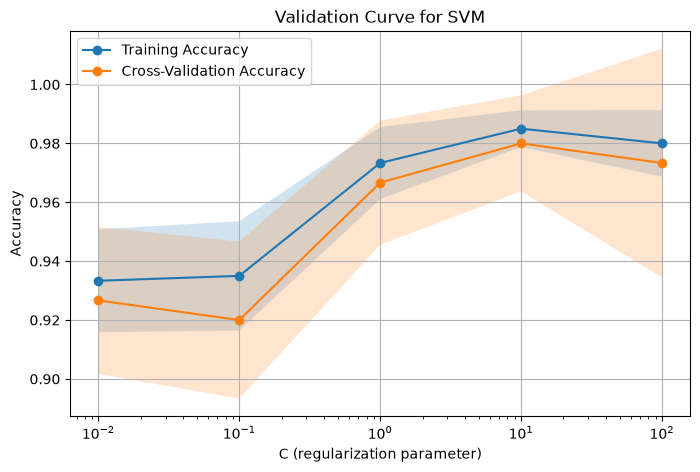

In [12]:
print("\n" + "=" * 60)
print("STEP 8: Choosing Hyperparameters – Validation Curve")
print("=" * 60)

# Let's tune 'C' for SVM using validation curve
param_range = [0.01, 0.1, 1, 10, 100]
train_scores, test_scores = validation_curve(
    SVC(kernel='rbf', gamma='scale', random_state=42),
    X_clf, y_clf,
    param_name='C',
    param_range=param_range,
    cv=5,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(param_range, train_mean, label='Training Accuracy', marker='o')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.plot(param_range, test_mean, label='Cross-Validation Accuracy', marker='o')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2)
plt.xscale('log')
plt.xlabel('C (regularization parameter)')
plt.ylabel('Accuracy')
plt.title('Validation Curve for SVM')
plt.legend()
plt.grid(True)
plt.show()


## 9. Avoiding Overfitting


In [13]:
print("\n" + "=" * 60)
print("STEP 9: Avoiding Overfitting – Regularization and Early Stopping")
print("=" * 60)

# Demonstrate overfitting with a deep tree vs regularized tree on a small dataset
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)

# Unrestricted tree (likely overfit)
dt_deep = RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=2, random_state=42)
dt_deep.fit(X_train, y_train)
train_acc_deep = accuracy_score(y_train, dt_deep.predict(X_train))
test_acc_deep = accuracy_score(y_test, dt_deep.predict(X_test))

# Regularized tree (max_depth=4)
dt_reg = RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_split=5, random_state=42)
dt_reg.fit(X_train, y_train)
train_acc_reg = accuracy_score(y_train, dt_reg.predict(X_train))
test_acc_reg = accuracy_score(y_test, dt_reg.predict(X_test))

print(f"Unrestricted Tree: Train accuracy = {train_acc_deep:.4f}, Test accuracy = {test_acc_deep:.4f}")
print(f"Regularized Tree:  Train accuracy = {train_acc_reg:.4f}, Test accuracy = {test_acc_reg:.4f}")
print("Conclusion: Regularization (max_depth, min_samples_split) reduces overfitting.")



STEP 9: Avoiding Overfitting – Regularization and Early Stopping


Unrestricted Tree: Train accuracy = 1.0000, Test accuracy = 1.0000
Regularized Tree:  Train accuracy = 0.9619, Test accuracy = 1.0000
Conclusion: Regularization (max_depth, min_samples_split) reduces overfitting.


## 10. Summary


In [14]:
print("\n" + "=" * 60)
print("📊 Mini Project Complete!")
print("=" * 60)
print("Model selection and tuning techniques covered:")
print(" ✅ Cross-Validation (basic)")
print(" ✅ K-Fold CV")
print(" ✅ Stratified K-Fold")
print(" ✅ Leave-One-Out (LOO)")
print(" ✅ GridSearchCV – exhaustive search")
print(" ✅ RandomizedSearchCV – random search")
print(" ✅ HalvingGridSearchCV – successive halving")
print(" ✅ Choosing hyperparameters via validation curves")
print(" ✅ Avoiding overfitting with regularization")
print("\nRecommendations:")
print("- Use StratifiedKFold for classification to maintain class distribution.")
print("- GridSearch is thorough but expensive; use RandomizedSearch for large spaces.")
print("- HalvingGridSearch is efficient for large grids.")
print("- Always use cross-validation, not a single train/test split, for tuning.")
print("- Check validation curves to select sensible hyperparameter ranges.")
print("- Regularize to avoid overfitting, especially with complex models.")


📊 Mini Project Complete!
Model selection and tuning techniques covered:
 ✅ Cross-Validation (basic)
 ✅ K-Fold CV
 ✅ Stratified K-Fold
 ✅ Leave-One-Out (LOO)
 ✅ GridSearchCV – exhaustive search
 ✅ RandomizedSearchCV – random search
 ✅ HalvingGridSearchCV – successive halving
 ✅ Choosing hyperparameters via validation curves
 ✅ Avoiding overfitting with regularization

Recommendations:
- Use StratifiedKFold for classification to maintain class distribution.
- GridSearch is thorough but expensive; use RandomizedSearch for large spaces.
- HalvingGridSearch is efficient for large grids.
- Always use cross-validation, not a single train/test split, for tuning.
- Check validation curves to select sensible hyperparameter ranges.
- Regularize to avoid overfitting, especially with complex models.
